<a href="https://colab.research.google.com/github/pejmanrasti/EPU_ML_Angers_2026/blob/main/Jour%201/alzheimer_detection_classification_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Détection et Classification de la Maladie d'Alzheimer par Machine Learning

## 1. Définition du Problème

La maladie d'Alzheimer est la principale cause de démence, représentant environ deux tiers des cas. Les IRM cérébrales permettent de détecter des signes caractéristiques : ventricules élargis et amincissement de la matière grise corticale.

Le dataset utilisé (Kaggle) contient des IRM classées en 4 catégories :

| Classe | Label | Description |
|---|---|---|
| Non Dément | 0 | Pas de signe d'Alzheimer |
| Très légèrement dément | 1 | Premiers oublis, difficile à détecter |
| Légèrement dément | 2 | Perte de mots, désorientation |
| Modérément dément | 3 | Oubli des activités récentes, dépendance |

## 2. Objectifs Pédagogiques

Ce notebook explore **deux axes** :

**Axe A – Comparaison de classifieurs** sur image aplatie (flatten) :
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM, noyau RBF)
- Decision Tree (DT)
- Random Forest (RF)

**Axe B – Extraction de caractéristiques LBP** :
- Local Binary Patterns (LBP) comme descripteur de texture
- Ré-entraînement du meilleur classifieurs avec ces features
- Comparaison : *flatten brut* vs *features LBP*

## 3. Configuration de l'Environnement

In [1]:
# ─── Imports ───────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
import os
from glob import glob
from PIL import Image
from tqdm.notebook import tqdm

# scikit-image pour LBP
from skimage.feature import local_binary_pattern
from skimage.color import rgb2gray

# Prétraitement
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Classifieurs
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Métriques
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid', palette='muted')
print("Environnement prêt ✓")

Environnement prêt ✓


In [2]:
# ─── Montage Google Drive et décompression ─────────────────────────────────
from google.colab import drive
root = '/content/gdrive/'
drive.mount(root)

!unzip /content/gdrive/MyDrive/Formation_ICO/Jour1/data.zip -d /content/data

Streaming output truncated to the last 5000 lines.
  inflating: /content/data/Non_Demented/non_2057.jpg  
  inflating: /content/data/__MACOSX/Non_Demented/._non_2057.jpg  
  inflating: /content/data/Non_Demented/non_2731.jpg  
  inflating: /content/data/__MACOSX/Non_Demented/._non_2731.jpg  
  inflating: /content/data/Non_Demented/non_1238.jpg  
  inflating: /content/data/__MACOSX/Non_Demented/._non_1238.jpg  
  inflating: /content/data/Non_Demented/non_2725.jpg  
  inflating: /content/data/__MACOSX/Non_Demented/._non_2725.jpg  
  inflating: /content/data/Non_Demented/non_2043.jpg  
  inflating: /content/data/__MACOSX/Non_Demented/._non_2043.jpg  
  inflating: /content/data/Non_Demented/non_1562.jpg  
  inflating: /content/data/__MACOSX/Non_Demented/._non_1562.jpg  
  inflating: /content/data/Non_Demented/non_1204.jpg  
  inflating: /content/data/__MACOSX/Non_Demented/._non_1204.jpg  
  inflating: /content/data/Non_Demented/non_2719.jpg  
  inflating: /content/data/__MACOSX/Non_Demente

## 4. Chargement et Exploration des Données

In [3]:
# ─── Chemins vers les 4 classes ────────────────────────────────────────────
# Adapter selon votre structure de répertoire après décompression
BASE_DIR = '/content/data'   # ou '/content/data' selon votre décompression

non       = sorted(glob(os.path.join(BASE_DIR, 'Non_Demented',       '*.jpg')))
very_mild = sorted(glob(os.path.join(BASE_DIR, 'Very_Mild_Demented', '*.jpg')))
mild      = sorted(glob(os.path.join(BASE_DIR, 'Mild_Demented',      '*.jpg')))
moderate  = sorted(glob(os.path.join(BASE_DIR, 'Moderate_Demented',  '*.jpg')))

CLASS_NAMES = ['Non Dément', 'Très légèrement', 'Légèrement', 'Modérément']
CLASS_DIRS  = [non, very_mild, mild, moderate]

print("Distribution des données :")
for name, d in zip(CLASS_NAMES, CLASS_DIRS):
    print(f"  {name:22s}: {len(d):5d} images")
print(f"  {'TOTAL':22s}: {sum(len(d) for d in CLASS_DIRS):5d} images")

Distribution des données :
  Non Dément            :  3200 images
  Très légèrement       :  2240 images
  Légèrement            :   896 images
  Modérément            :    64 images
  TOTAL                 :  6400 images


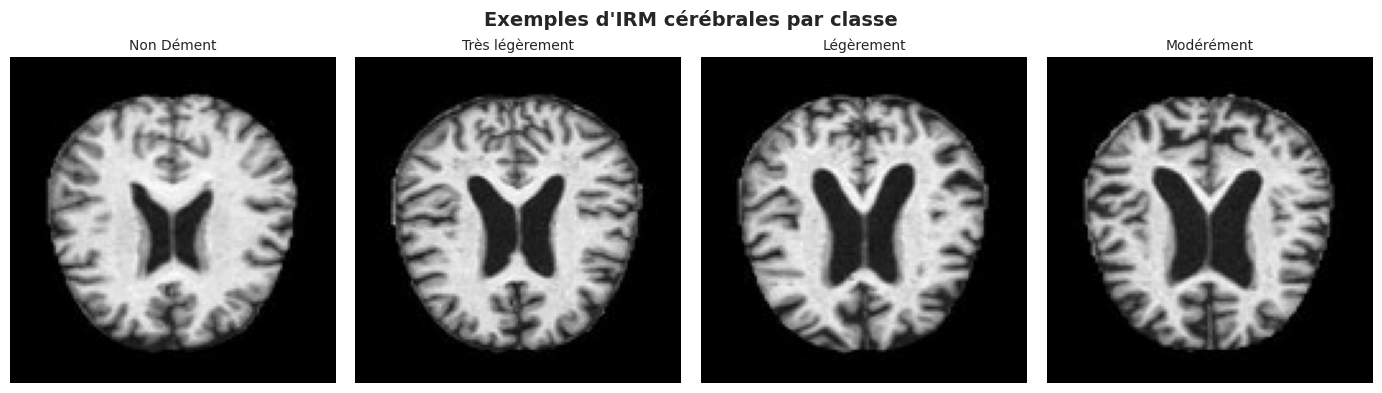

In [4]:
# ─── Visualisation d'un échantillon par classe ─────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle("Exemples d'IRM cérébrales par classe", fontsize=14, fontweight='bold')

for ax, class_dir, name in zip(axes, CLASS_DIRS, CLASS_NAMES):
    img = Image.open(class_dir[0]).convert('L')  # niveaux de gris
    ax.imshow(img, cmap='gray')
    ax.set_title(name, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

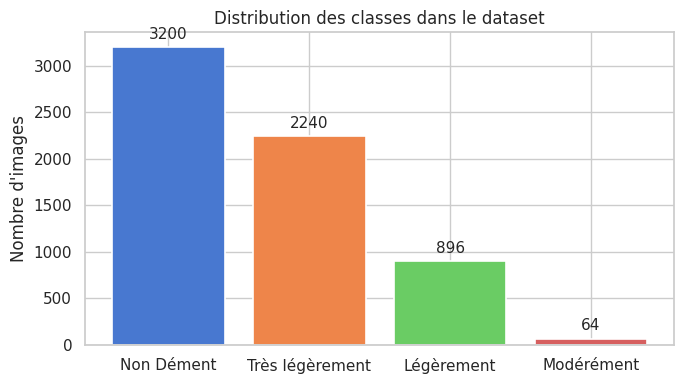


⚠️  Déséquilibre de classes : à garder en tête pour l'interprétation des résultats.


In [5]:
# ─── Distribution des classes (diagramme barre) ────────────────────────────
counts = [len(d) for d in CLASS_DIRS]
colors = sns.color_palette('muted', 4)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(CLASS_NAMES, counts, color=colors, edgecolor='white', linewidth=1.2)
ax.bar_label(bars, padding=4, fontsize=11)
ax.set_ylabel("Nombre d'images")
ax.set_title("Distribution des classes dans le dataset")
plt.tight_layout()
plt.show()

print("\n⚠️  Déséquilibre de classes : à garder en tête pour l'interprétation des résultats.")

## 5. Préparation des Données

Nous préparons **deux représentations** de chaque image :

1. **Flatten** : vecteur brut de pixels (128×128 = 16 384 dimensions)
2. **LBP** : histogramme Local Binary Patterns (texture locale, ~59 dimensions en mode `uniform`)

### 5.1 Paramètres globaux

In [6]:
# ─── Paramètres ─────────────────────────────────────────────────────────────
IMG_SIZE   = (128, 128)   # taille de redimensionnement

# Paramètres LBP
LBP_RADIUS = 1            # rayon du voisinage
LBP_POINTS = 8 * LBP_RADIUS  # nombre de points d'échantillonnage
LBP_METHOD = 'uniform'    # mode uniforme → ~59 patterns invariants à la rotation

print(f"Taille image  : {IMG_SIZE}")
print(f"Dim. flatten  : {IMG_SIZE[0]*IMG_SIZE[1]} features")
print(f"LBP points    : {LBP_POINTS}, rayon : {LBP_RADIUS}")
print(f"Dim. LBP hist : {LBP_POINTS + 2} bins (mode '{LBP_METHOD}')")

Taille image  : (128, 128)
Dim. flatten  : 16384 features
LBP points    : 8, rayon : 1
Dim. LBP hist : 10 bins (mode 'uniform')


### 5.2 Extraction Flatten et LBP

In [7]:
def compute_lbp_histogram(gray_img):
    """
    Calcule l'histogramme LBP normalisé d'une image en niveaux de gris.

    Le LBP encode la texture locale : pour chaque pixel, il compare sa valeur
    à ses voisins et produit un code binaire. L'histogramme de ces codes
    forme un descripteur compact et robuste aux changements d'illumination.
    """
    lbp = local_binary_pattern(gray_img, LBP_POINTS, LBP_RADIUS, method=LBP_METHOD)
    n_bins = LBP_POINTS + 2  # pour le mode 'uniform'
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)
    return hist


def load_dataset(class_dirs, class_labels, img_size=IMG_SIZE):
    """
    Charge toutes les images, retourne :
      - X_flat  : features flatten (pixels bruts normalisés)
      - X_lbp   : features LBP (histogramme de texture)
      - y       : labels de classe
    """
    X_flat_list, X_lbp_list, y_list = [], [], []

    for label, class_dir in zip(class_labels, class_dirs):
        for filepath in tqdm(class_dir, desc=f'Classe {label}', leave=False):
            img = Image.open(filepath).convert('L')  # niveau de gris
            img = img.resize(img_size)
            arr = np.array(img)

            # ── Flatten ──────────────────────────────────────────────────────
            X_flat_list.append(arr.flatten())

            # ── LBP ──────────────────────────────────────────────────────────
            lbp_hist = compute_lbp_histogram(arr)
            X_lbp_list.append(lbp_hist)

            y_list.append(label)

    X_flat = np.array(X_flat_list, dtype=np.float32)
    X_lbp  = np.array(X_lbp_list,  dtype=np.float32)
    y      = np.array(y_list,       dtype=np.int32)
    return X_flat, X_lbp, y


print("Chargement des images (4 classes × plusieurs centaines d'images)…")
X_flat, X_lbp, y = load_dataset(
    class_dirs   = CLASS_DIRS,
    class_labels = [0, 1, 2, 3]
)
print(f"\nDonnées chargées :")
print(f"  X_flat  : {X_flat.shape}  → {X_flat.shape[1]} features (pixels bruts)")
print(f"  X_lbp   : {X_lbp.shape}   → {X_lbp.shape[1]}  features (histogramme LBP)")
print(f"  y       : {y.shape}    → classes {np.unique(y)}")

Chargement des images (4 classes × plusieurs centaines d'images)…


Classe 0:   0%|          | 0/3200 [00:00<?, ?it/s]

Classe 1:   0%|          | 0/2240 [00:00<?, ?it/s]

Classe 2:   0%|          | 0/896 [00:00<?, ?it/s]

Classe 3:   0%|          | 0/64 [00:00<?, ?it/s]


Données chargées :
  X_flat  : (6400, 16384)  → 16384 features (pixels bruts)
  X_lbp   : (6400, 10)   → 10  features (histogramme LBP)
  y       : (6400,)    → classes [0 1 2 3]


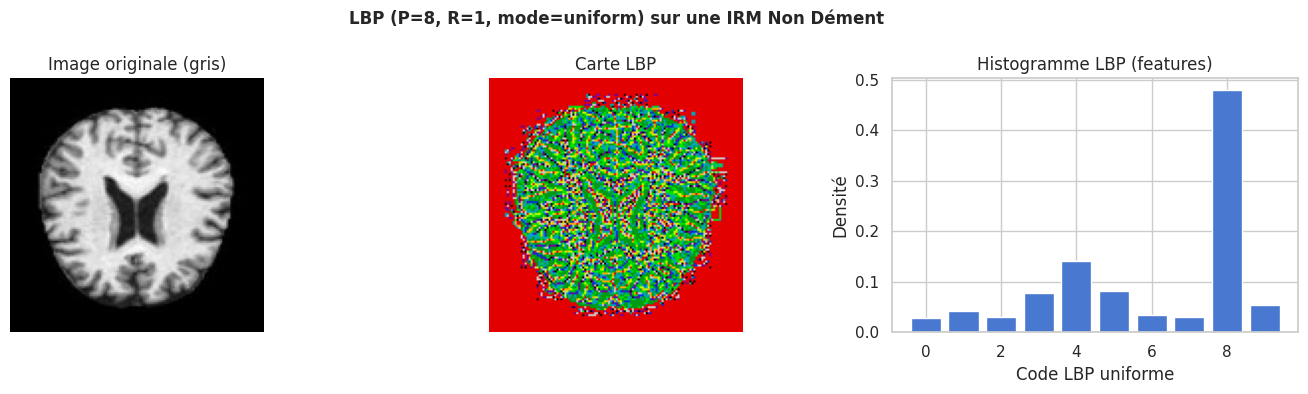


Interprétation LBP :
  • Chaque pixel est encodé en comparant son intensité à ses voisins → code binaire
  • Mode 'uniform' : garde les ~59 patterns les plus stables (peu de transitions 0→1)
  • L'histogramme agrège cette information en un vecteur compact de 10 valeurs
  • Avantage : invariant aux changements d'éclairage uniforme, faible dimensionnalité



In [8]:
# ─── Visualisation LBP sur un exemple ─────────────────────────────────────
sample_path = non[0]
sample_img  = np.array(Image.open(sample_path).convert('L').resize(IMG_SIZE))
sample_lbp  = local_binary_pattern(sample_img, LBP_POINTS, LBP_RADIUS, method=LBP_METHOD)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(sample_img, cmap='gray')
axes[0].set_title('Image originale (gris)')
axes[0].axis('off')

axes[1].imshow(sample_lbp, cmap='nipy_spectral')
axes[1].set_title('Carte LBP')
axes[1].axis('off')

n_bins = LBP_POINTS + 2
hist, _ = np.histogram(sample_lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)
axes[2].bar(range(n_bins), hist, color=sns.color_palette('muted')[0])
axes[2].set_title('Histogramme LBP (features)')
axes[2].set_xlabel('Code LBP uniforme')
axes[2].set_ylabel('Densité')

fig.suptitle(
    f'LBP (P={LBP_POINTS}, R={LBP_RADIUS}, mode={LBP_METHOD}) sur une IRM Non Dément',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

print("""
Interprétation LBP :
  • Chaque pixel est encodé en comparant son intensité à ses voisins → code binaire
  • Mode 'uniform' : garde les ~59 patterns les plus stables (peu de transitions 0→1)
  • L'histogramme agrège cette information en un vecteur compact de 10 valeurs
  • Avantage : invariant aux changements d'éclairage uniforme, faible dimensionnalité
""")

### 5.3 Découpage Train / Test et Normalisation

In [9]:
# ─── Split stratifié (80/20) ───────────────────────────────────────────────
# stratify=y assure que chaque classe est représentée proportionnellement
X_flat_tr, X_flat_te, y_tr, y_te = train_test_split(
    X_flat, y, test_size=0.2, random_state=42, stratify=y
)
X_lbp_tr, X_lbp_te, _, _ = train_test_split(
    X_lbp, y, test_size=0.2, random_state=42, stratify=y
)

# ─── Normalisation (z-score) ───────────────────────────────────────────────
# Important pour KNN et SVM qui sont sensibles à l'échelle des features
scaler_flat = StandardScaler()
X_flat_tr_s = scaler_flat.fit_transform(X_flat_tr)
X_flat_te_s = scaler_flat.transform(X_flat_te)

scaler_lbp = StandardScaler()
X_lbp_tr_s = scaler_lbp.fit_transform(X_lbp_tr)
X_lbp_te_s = scaler_lbp.transform(X_lbp_te)

print("Découpage et normalisation :")
print(f"  Train flatten : {X_flat_tr_s.shape}")
print(f"  Test  flatten : {X_flat_te_s.shape}")
print(f"  Train LBP     : {X_lbp_tr_s.shape}")
print(f"  Test  LBP     : {X_lbp_te_s.shape}")
print(f"\n  Distribution classes (train) : {dict(zip(*np.unique(y_tr, return_counts=True)))}")
print(f"  Distribution classes (test)  : {dict(zip(*np.unique(y_te, return_counts=True)))}")

Découpage et normalisation :
  Train flatten : (5120, 16384)
  Test  flatten : (1280, 16384)
  Train LBP     : (5120, 10)
  Test  LBP     : (1280, 10)

  Distribution classes (train) : {np.int32(0): np.int64(2560), np.int32(1): np.int64(1792), np.int32(2): np.int64(717), np.int32(3): np.int64(51)}
  Distribution classes (test)  : {np.int32(0): np.int64(640), np.int32(1): np.int64(448), np.int32(2): np.int64(179), np.int32(3): np.int64(13)}


## 6. Axe A – Comparaison de Classifieurs sur Features Flatten

Nous entraînons et évaluons les 4 classifieurs avec une **matrice de confusion** et un **rapport de classification** pour chacun.

### Rappel théorique des classifieurs :

| Classifieur | Principe | Hyper-param. clé | Complexité |
|---|---|---|---|
| **KNN** | Vote des k voisins les plus proches | k (nombre de voisins) | O(n·d) à l'inférence |
| **SVM** | Marge maximale entre classes (noyau RBF) | C, γ | Quadratique en n |
| **DT** | Arbre de décision (splits récursifs) | max_depth | O(d·n·log n) |
| **RF** | Ensemble d'arbres aléatoires (bagging) | n_estimators, max_depth | O(T·d·n·log n) |

In [10]:
# ─── Utilitaire d'évaluation ────────────────────────────────────────────────
def evaluate_classifier(clf, X_tr, X_te, y_tr, y_te,
                         clf_name, feature_name, class_names=CLASS_NAMES):
    """
    Entraîne un classifieur, affiche les métriques + matrice de confusion.
    Retourne un dict récapitulatif.
    """
    # ── Entraînement ────────────────────────────────────────────────────────
    clf.fit(X_tr, y_tr)

    # ── Prédictions ─────────────────────────────────────────────────────────
    y_pred_tr = clf.predict(X_tr)
    y_pred_te = clf.predict(X_te)

    acc_tr = accuracy_score(y_tr, y_pred_tr)
    acc_te = accuracy_score(y_te, y_pred_te)

    print(f"\n{'='*60}")
    print(f"  {clf_name}  |  Features : {feature_name}")
    print(f"{'='*60}")
    print(f"  Accuracy  train : {acc_tr:.4f}    test : {acc_te:.4f}")
    print(f"  Overfitting gap : {acc_tr - acc_te:.4f}")
    print()
    print("  Rapport de classification (test) :")
    print(classification_report(y_te, y_pred_te, target_names=class_names,
                                  digits=3, zero_division=0))

    # ── Matrice de confusion ─────────────────────────────────────────────────
    cm = confusion_matrix(y_te, y_pred_te)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=30)
    ax.set_title(f'Matrice de confusion – {clf_name}\n(Features : {feature_name})',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return {
        'Classifieur' : clf_name,
        'Features'    : feature_name,
        'Acc_train'   : round(acc_tr, 4),
        'Acc_test'    : round(acc_te, 4),
        'F1_macro'    : round(f1_score(y_te, y_pred_te, average='macro', zero_division=0), 4)
    }

print("Fonction d'évaluation définie ✓")

Fonction d'évaluation définie ✓


### 6.1 K-Nearest Neighbors (KNN)

Le KNN est un classifieur **non-paramétrique** : il mémorise l'ensemble d'entraînement et classe chaque test sample par vote majoritaire de ses k voisins les plus proches (distance euclidienne dans l'espace des features).

**Limites attendues** : sur des vecteurs de 16 384 dimensions (flatten de pixels), la distance euclidienne devient peu discriminante (*malédiction de la dimensionnalité*).


  KNN (k=5)  |  Features : Flatten 128×128
  Accuracy  train : 0.9932    test : 0.9727
  Overfitting gap : 0.0205

  Rapport de classification (test) :
                 precision    recall  f1-score   support

     Non Dément      0.961     0.991     0.975       640
Très légèrement      0.979     0.953     0.966       448
     Légèrement      1.000     0.961     0.980       179
     Modérément      1.000     0.923     0.960        13

       accuracy                          0.973      1280
      macro avg      0.985     0.957     0.970      1280
   weighted avg      0.973     0.973     0.973      1280



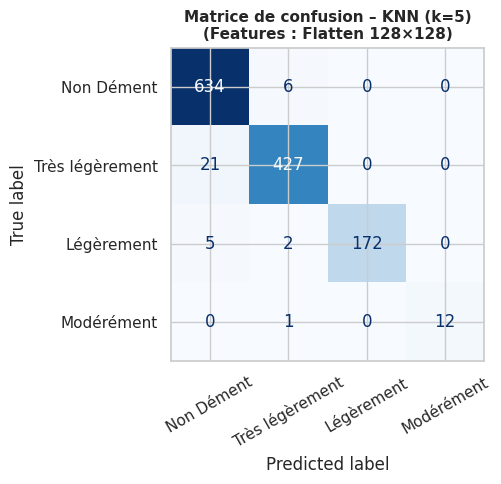

In [11]:
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean', n_jobs=-1)
res_knn_flat = evaluate_classifier(
    knn, X_flat_tr_s, X_flat_te_s, y_tr, y_te,
    clf_name='KNN (k=5)', feature_name='Flatten 128×128'
)

### 6.2 Support Vector Machine (SVM – noyau RBF)

Le SVM cherche l'hyperplan de marge maximale séparant les classes dans un espace de haute dimension. Le **noyau RBF** (Radial Basis Function) permet de traiter des frontières non-linéaires. C'est souvent le classifieur le plus robuste sur des features d'images dans le régime classique (non-deep).


  SVM (RBF)  |  Features : Flatten 128×128
  Accuracy  train : 1.0000    test : 0.9953
  Overfitting gap : 0.0047

  Rapport de classification (test) :
                 precision    recall  f1-score   support

     Non Dément      0.995     0.998     0.997       640
Très légèrement      0.993     0.996     0.994       448
     Légèrement      1.000     0.989     0.994       179
     Modérément      1.000     0.923     0.960        13

       accuracy                          0.995      1280
      macro avg      0.997     0.976     0.986      1280
   weighted avg      0.995     0.995     0.995      1280



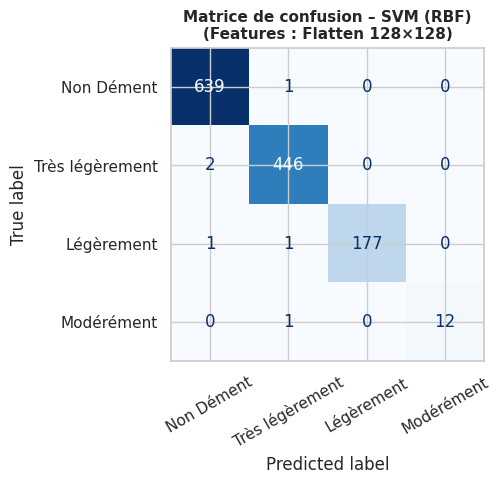

In [12]:
svm_clf = svm.SVC(kernel='rbf', C=10, gamma='scale', decision_function_shape='ovr',
                  random_state=42)
res_svm_flat = evaluate_classifier(
    svm_clf, X_flat_tr_s, X_flat_te_s, y_tr, y_te,
    clf_name='SVM (RBF)', feature_name='Flatten 128×128'
)

### 6.3 Decision Tree (DT)

L'arbre de décision construit récursivement des **règles de partitionnement** (splits) sur les features en maximisant le gain d'information (Gini ou entropie). Il est interprétable mais tend à **surapprendres** (overfitting) si non élagué.


  Decision Tree (depth=15)  |  Features : Flatten 128×128
  Accuracy  train : 0.9357    test : 0.7125
  Overfitting gap : 0.2232

  Rapport de classification (test) :
                 precision    recall  f1-score   support

     Non Dément      0.755     0.798     0.776       640
Très légèrement      0.688     0.683     0.685       448
     Légèrement      0.606     0.525     0.563       179
     Modérément      0.333     0.077     0.125        13

       accuracy                          0.713      1280
      macro avg      0.596     0.521     0.537      1280
   weighted avg      0.706     0.713     0.708      1280



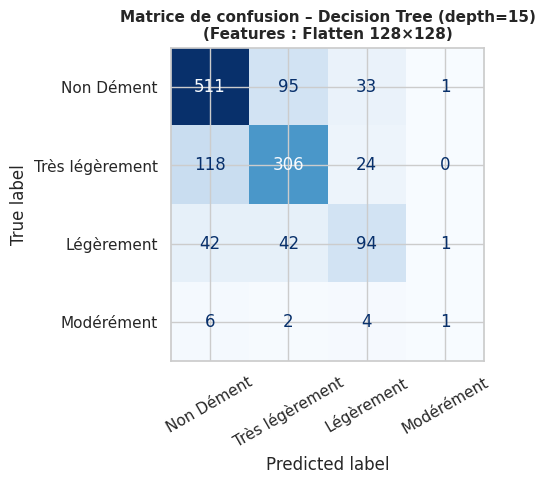

In [13]:
dt = DecisionTreeClassifier(criterion='gini', max_depth=15,
                              min_samples_leaf=5, random_state=42)
res_dt_flat = evaluate_classifier(
    dt, X_flat_tr_s, X_flat_te_s, y_tr, y_te,
    clf_name='Decision Tree (depth=15)', feature_name='Flatten 128×128'
)

### 6.4 Random Forest (RF)

La Forêt Aléatoire combine **N arbres de décision** entraînés sur des sous-échantillons bootstrap et sur des sous-ensembles aléatoires de features (bagging + feature randomness). Le vote majoritaire réduit la variance et l'overfitting par rapport à un arbre seul.


  Random Forest (100 arbres)  |  Features : Flatten 128×128
  Accuracy  train : 1.0000    test : 0.8914
  Overfitting gap : 0.1086

  Rapport de classification (test) :
                 precision    recall  f1-score   support

     Non Dément      0.865     0.989     0.923       640
Très légèrement      0.906     0.857     0.881       448
     Légèrement      1.000     0.682     0.811       179
     Modérément      1.000     0.154     0.267        13

       accuracy                          0.891      1280
      macro avg      0.943     0.670     0.720      1280
   weighted avg      0.899     0.891     0.886      1280



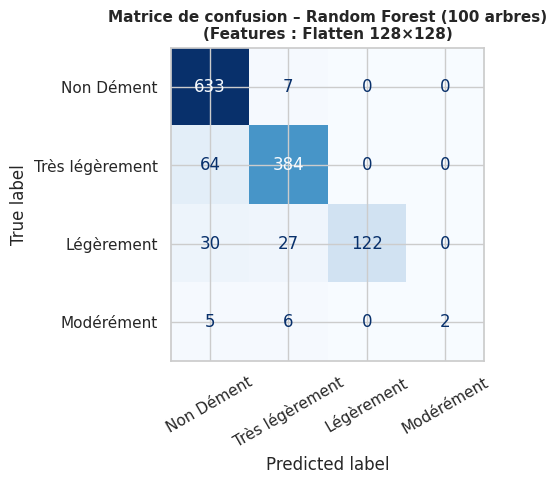

In [14]:
rf = RandomForestClassifier(n_estimators=100, max_depth=20, min_samples_leaf=2,
                              n_jobs=-1, random_state=42)
res_rf_flat = evaluate_classifier(
    rf, X_flat_tr_s, X_flat_te_s, y_tr, y_te,
    clf_name='Random Forest (100 arbres)', feature_name='Flatten 128×128'
)

## 7. Tableau Comparatif – Axe A (Flatten)


=== Récapitulatif Axe A : Features Flatten ===
               Classifieur        Features  Acc_train  Acc_test  F1_macro  Gap_overfit
                 KNN (k=5) Flatten 128×128     0.9932    0.9727    0.9704       0.0205
                 SVM (RBF) Flatten 128×128     1.0000    0.9953    0.9864       0.0047
  Decision Tree (depth=15) Flatten 128×128     0.9357    0.7125    0.5373       0.2232
Random Forest (100 arbres) Flatten 128×128     1.0000    0.8914    0.7202       0.1086


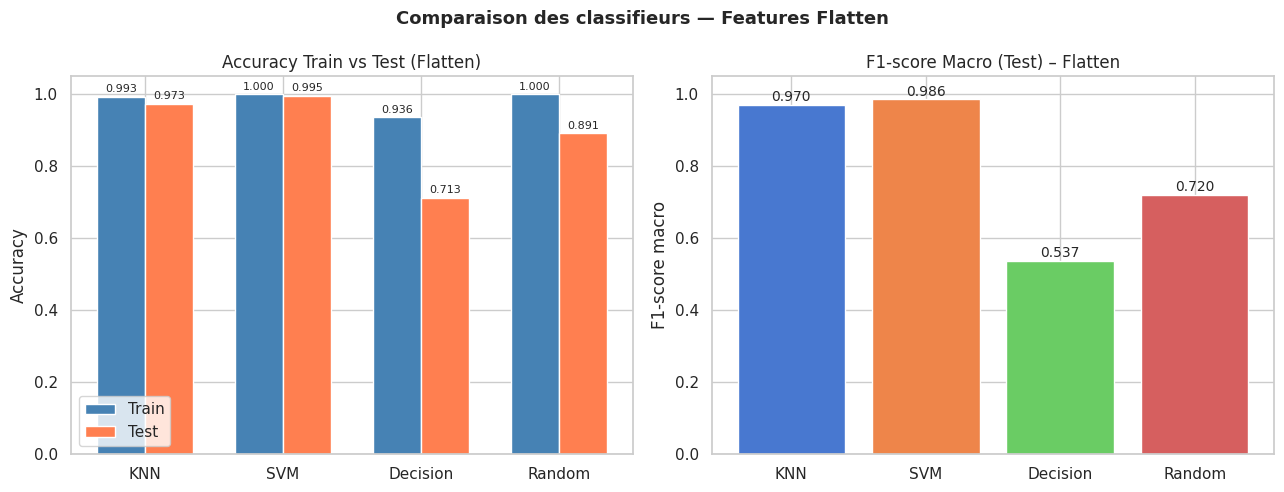

In [15]:
results_flat = pd.DataFrame([
    res_knn_flat, res_svm_flat, res_dt_flat, res_rf_flat
])
results_flat['Gap_overfit'] = results_flat['Acc_train'] - results_flat['Acc_test']

print("\n=== Récapitulatif Axe A : Features Flatten ===")
print(results_flat.to_string(index=False))

# ── Graphe comparatif ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(results_flat))
w = 0.35
clf_labels = [r['Classifieur'].split()[0] for r in [res_knn_flat, res_svm_flat, res_dt_flat, res_rf_flat]]

bars_tr = axes[0].bar(x - w/2, results_flat['Acc_train'], w, label='Train', color='steelblue')
bars_te = axes[0].bar(x + w/2, results_flat['Acc_test'],  w, label='Test',  color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(clf_labels)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy Train vs Test (Flatten)')
axes[0].legend()
axes[0].bar_label(bars_tr, fmt='%.3f', padding=2, fontsize=8)
axes[0].bar_label(bars_te, fmt='%.3f', padding=2, fontsize=8)

colors_f1 = sns.color_palette('muted', len(results_flat))
axes[1].bar(clf_labels, results_flat['F1_macro'], color=colors_f1)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('F1-score macro')
axes[1].set_title('F1-score Macro (Test) – Flatten')
for i, v in enumerate(results_flat['F1_macro']):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

plt.suptitle('Comparaison des classifieurs — Features Flatten', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Axe B – Features LBP avec le Meilleur Classifieur

Nous identifions le classifieur le plus performant (F1 macro) sur les features flatten, puis le ré-entraînons sur les features **LBP**. L'objectif est de comparer :

> **Pixels bruts (16 384 dim)** vs **Histogramme LBP (10 dim)**

Le LBP encode la **structure locale de texture** des IRM, ce qui est potentiellement plus pertinent que les valeurs pixel absolues pour distinguer les niveaux d'atrophie cérébrale.

### 8.1 Identification du meilleur classifieur

In [16]:
# ─── Identifier le meilleur classifieur (F1 macro test) ────────────────────
best_idx   = results_flat['F1_macro'].idxmax()
best_row   = results_flat.loc[best_idx]
best_name  = best_row['Classifieur']

print(f"Meilleur classifieur (Axe A, F1 macro) : {best_name}")
print(f"  Acc test  = {best_row['Acc_test']:.4f}")
print(f"  F1 macro  = {best_row['F1_macro']:.4f}")

# Réinstancier le même classifieur avec les mêmes hyperparamètres
classifiers_map = {
    'KNN'     : KNeighborsClassifier(n_neighbors=5, metric='euclidean', n_jobs=-1),
    'SVM'     : svm.SVC(kernel='rbf', C=10, gamma='scale',
                         decision_function_shape='ovr', random_state=42),
    'Decision': DecisionTreeClassifier(criterion='gini', max_depth=15,
                                        min_samples_leaf=5, random_state=42),
    'Random'  : RandomForestClassifier(n_estimators=100, max_depth=20,
                                        min_samples_leaf=2, n_jobs=-1, random_state=42)
}
# Choisir selon le préfixe du nom
best_clf_key = next(k for k in classifiers_map if best_name.startswith(k))
best_clf_lbp = classifiers_map[best_clf_key]
print(f"Classifieur sélectionné pour l'Axe B : {best_clf_key}")

Meilleur classifieur (Axe A, F1 macro) : SVM (RBF)
  Acc test  = 0.9953
  F1 macro  = 0.9864
Classifieur sélectionné pour l'Axe B : SVM


### 8.2 Entraînement et Évaluation du Meilleur Classifieur sur LBP

Pour être exhaustif et permettre une vraie comparaison, nous entraînons **tous** les classifieurs sur les features LBP.


  KNN (k=5)  |  Features : LBP Histogramme
  Accuracy  train : 0.6562    test : 0.5242
  Overfitting gap : 0.1320

  Rapport de classification (test) :
                 precision    recall  f1-score   support

     Non Dément      0.574     0.755     0.652       640
Très légèrement      0.462     0.393     0.425       448
     Légèrement      0.214     0.067     0.102       179
     Modérément      0.000     0.000     0.000        13

       accuracy                          0.524      1280
      macro avg      0.312     0.304     0.295      1280
   weighted avg      0.478     0.524     0.489      1280



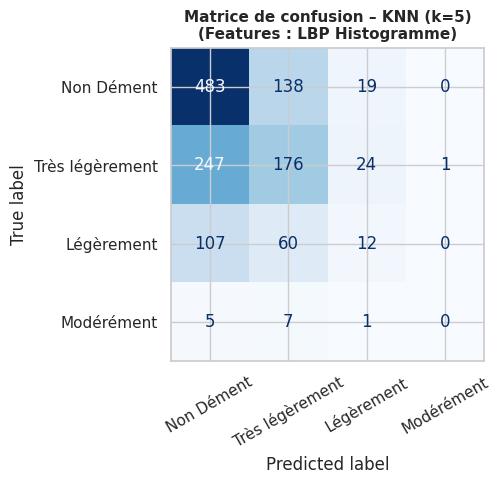


  SVM (RBF)  |  Features : LBP Histogramme
  Accuracy  train : 0.6326    test : 0.5273
  Overfitting gap : 0.1053

  Rapport de classification (test) :
                 precision    recall  f1-score   support

     Non Dément      0.564     0.781     0.655       640
Très légèrement      0.458     0.382     0.417       448
     Légèrement      0.190     0.022     0.040       179
     Modérément      0.000     0.000     0.000        13

       accuracy                          0.527      1280
      macro avg      0.303     0.296     0.278      1280
   weighted avg      0.469     0.527     0.479      1280



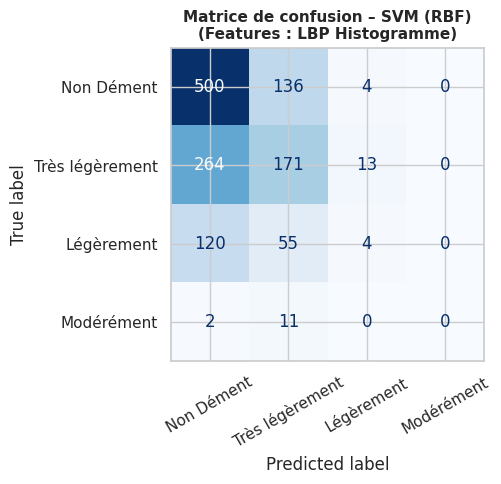


  Decision Tree (depth=15)  |  Features : LBP Histogramme
  Accuracy  train : 0.7564    test : 0.4516
  Overfitting gap : 0.3049

  Rapport de classification (test) :
                 precision    recall  f1-score   support

     Non Dément      0.539     0.586     0.561       640
Très légèrement      0.380     0.411     0.395       448
     Légèrement      0.190     0.106     0.136       179
     Modérément      0.000     0.000     0.000        13

       accuracy                          0.452      1280
      macro avg      0.277     0.276     0.273      1280
   weighted avg      0.429     0.452     0.438      1280



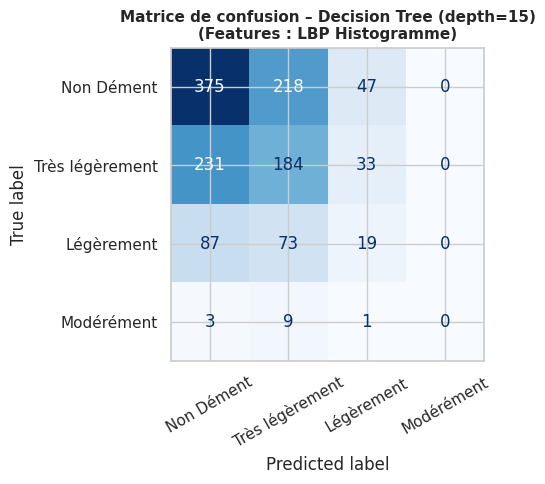


  Random Forest (100 arbres)  |  Features : LBP Histogramme
  Accuracy  train : 0.9875    test : 0.5227
  Overfitting gap : 0.4648

  Rapport de classification (test) :
                 precision    recall  f1-score   support

     Non Dément      0.560     0.783     0.653       640
Très légèrement      0.452     0.355     0.398       448
     Légèrement      0.273     0.050     0.085       179
     Modérément      0.000     0.000     0.000        13

       accuracy                          0.523      1280
      macro avg      0.321     0.297     0.284      1280
   weighted avg      0.476     0.523     0.477      1280



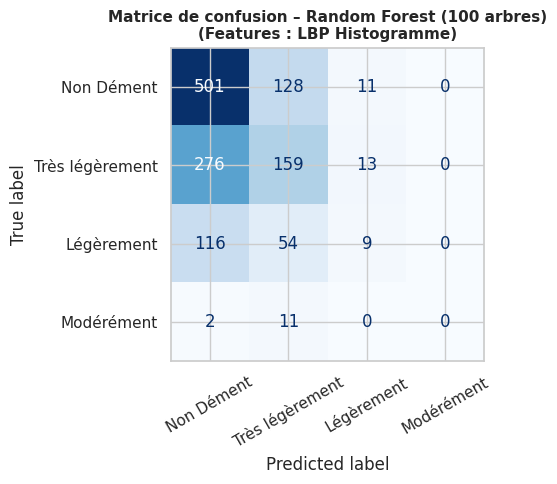

In [17]:
# ─── Tous les classifieurs sur LBP ─────────────────────────────────────────
clfs_lbp = {
    'KNN (k=5)'               : KNeighborsClassifier(n_neighbors=5, metric='euclidean', n_jobs=-1),
    'SVM (RBF)'               : svm.SVC(kernel='rbf', C=10, gamma='scale',
                                         decision_function_shape='ovr', random_state=42),
    'Decision Tree (depth=15)': DecisionTreeClassifier(criterion='gini', max_depth=15,
                                                         min_samples_leaf=5, random_state=42),
    'Random Forest (100 arbres)': RandomForestClassifier(n_estimators=100, max_depth=20,
                                                           min_samples_leaf=2, n_jobs=-1,
                                                           random_state=42)
}

results_lbp_list = []
for clf_name, clf in clfs_lbp.items():
    r = evaluate_classifier(
        clf, X_lbp_tr_s, X_lbp_te_s, y_tr, y_te,
        clf_name=clf_name, feature_name='LBP Histogramme'
    )
    results_lbp_list.append(r)

## 9. Comparaison Finale : Flatten vs LBP

In [18]:
results_lbp = pd.DataFrame(results_lbp_list)
results_lbp['Gap_overfit'] = results_lbp['Acc_train'] - results_lbp['Acc_test']

print("\n=== Récapitulatif Axe A : Features Flatten ===")
print(results_flat[['Classifieur', 'Acc_train', 'Acc_test', 'F1_macro', 'Gap_overfit']].to_string(index=False))

print("\n=== Récapitulatif Axe B : Features LBP ===")
print(results_lbp[['Classifieur', 'Acc_train', 'Acc_test', 'F1_macro', 'Gap_overfit']].to_string(index=False))

# ── Fusion des deux tableaux ─────────────────────────────────────────────────
all_results = pd.concat([results_flat, results_lbp], ignore_index=True)
all_results['Gap_overfit'] = all_results['Acc_train'] - all_results['Acc_test']


=== Récapitulatif Axe A : Features Flatten ===
               Classifieur  Acc_train  Acc_test  F1_macro  Gap_overfit
                 KNN (k=5)     0.9932    0.9727    0.9704       0.0205
                 SVM (RBF)     1.0000    0.9953    0.9864       0.0047
  Decision Tree (depth=15)     0.9357    0.7125    0.5373       0.2232
Random Forest (100 arbres)     1.0000    0.8914    0.7202       0.1086

=== Récapitulatif Axe B : Features LBP ===
               Classifieur  Acc_train  Acc_test  F1_macro  Gap_overfit
                 KNN (k=5)     0.6562    0.5242    0.2946       0.1320
                 SVM (RBF)     0.6326    0.5273    0.2780       0.1053
  Decision Tree (depth=15)     0.7564    0.4516    0.2731       0.3048
Random Forest (100 arbres)     0.9875    0.5227    0.2838       0.4648


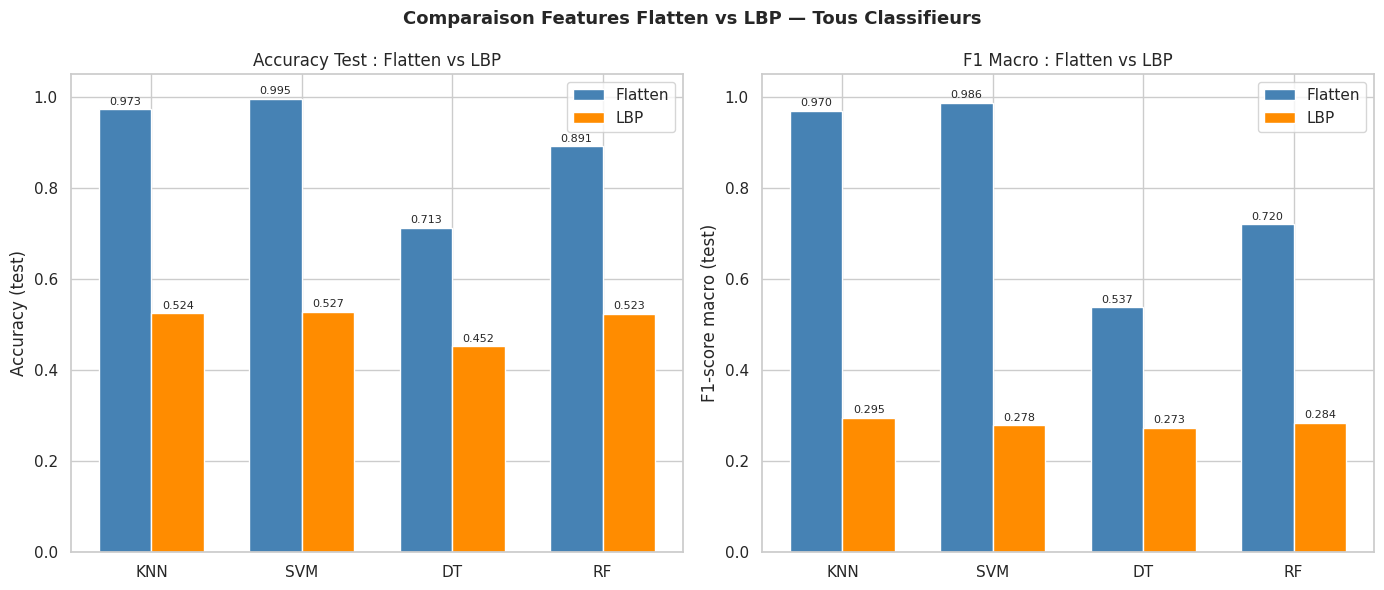

In [19]:
# ─── Graphique de comparaison Flatten vs LBP ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
clf_short = ['KNN', 'SVM', 'DT', 'RF']

# ── Accuracy test ────────────────────────────────────────────────────────────
x = np.arange(4)
w = 0.35
b1 = axes[0].bar(x - w/2, results_flat['Acc_test'], w, label='Flatten', color='steelblue')
b2 = axes[0].bar(x + w/2, results_lbp['Acc_test'],  w, label='LBP',     color='darkorange')
axes[0].set_xticks(x)
axes[0].set_xticklabels(clf_short)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('Accuracy (test)')
axes[0].set_title('Accuracy Test : Flatten vs LBP')
axes[0].legend()
axes[0].bar_label(b1, fmt='%.3f', padding=2, fontsize=8)
axes[0].bar_label(b2, fmt='%.3f', padding=2, fontsize=8)

# ── F1 macro test ────────────────────────────────────────────────────────────
b3 = axes[1].bar(x - w/2, results_flat['F1_macro'], w, label='Flatten', color='steelblue')
b4 = axes[1].bar(x + w/2, results_lbp['F1_macro'],  w, label='LBP',     color='darkorange')
axes[1].set_xticks(x)
axes[1].set_xticklabels(clf_short)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('F1-score macro (test)')
axes[1].set_title('F1 Macro : Flatten vs LBP')
axes[1].legend()
axes[1].bar_label(b3, fmt='%.3f', padding=2, fontsize=8)
axes[1].bar_label(b4, fmt='%.3f', padding=2, fontsize=8)

plt.suptitle('Comparaison Features Flatten vs LBP — Tous Classifieurs',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

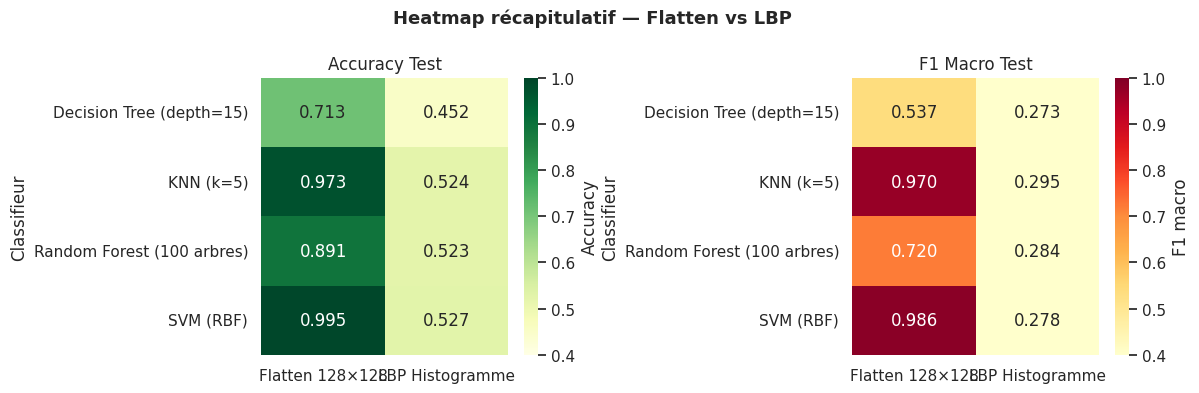

In [20]:
# ─── Heatmap récapitulatif ─────────────────────────────────────────────────
pivot_acc = all_results.pivot(index='Classifieur', columns='Features', values='Acc_test')
pivot_f1  = all_results.pivot(index='Classifieur', columns='Features', values='F1_macro')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(pivot_acc, annot=True, fmt='.3f', cmap='YlGn',
            vmin=0.4, vmax=1.0, ax=axes[0], cbar_kws={'label': 'Accuracy'})
axes[0].set_title('Accuracy Test')
axes[0].set_xlabel('')

sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0.4, vmax=1.0, ax=axes[1], cbar_kws={'label': 'F1 macro'})
axes[1].set_title('F1 Macro Test')
axes[1].set_xlabel('')

plt.suptitle('Heatmap récapitulatif — Flatten vs LBP', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Discussion et Conclusions

### 10.1 Comparaison des Classifieurs (Axe A – Flatten)

Discutez vos résultats en vous appuyant sur les métriques ci-dessus. Questions guides :

1. **Quel classifieur obtient les meilleures performances ?** Pourquoi le RF/SVM tend-il à dominer sur des espaces de haute dimension ?
2. **L'overfitting gap (acc_train − acc_test)** est-il préoccupant pour le DT ? Comparez-le au RF.
3. **Le KNN** est-il pénalisé par la malédiction de la dimensionnalité ? Que se passerait-il si vous réduisiez la dimension avec PCA avant KNN ?
4. **Matrices de confusion** : quelles classes sont les plus souvent confondues ? Est-ce cohérent cliniquement (classes adjacentes dans la progression de la maladie) ?

### 10.2 Flatten vs Features LBP (Axe B)

5. Les features LBP (10 valeurs) améliorent-elles les résultats par rapport aux pixels bruts (16 384 valeurs) ? Pourquoi ou pourquoi pas ?
6. **LBP capture la texture locale** (bords, motifs de tissu) mais perd l'information de forme globale (taille des ventricules, épaisseur corticale). Proposez une feature engineering complémentaire.
7. La **dimensionnalité réduite** du LBP accélère-t-elle l'entraînement de manière significative ?

### 10.3 Limites et Perspectives

8. Ce dataset est synthétique / augmenté : les performances sont-elles réalistes pour un contexte clinique réel ?
9. **Déséquilibre de classes** : quel impact sur les métriques ? Suggérez une stratégie (SMOTE, class_weight).
10. Prochaine étape naturelle : **deep learning** (CNN, ViT) qui apprend automatiquement des features hiérarchiques bien plus discriminantes que le LBP.

In [21]:
# ─── Synthèse finale ──────────────────────────────────────────────────────
print("=" * 65)
print("SYNTHÈSE FINALE")
print("=" * 65)

best_flat = results_flat.loc[results_flat['F1_macro'].idxmax()]
best_lbp  = results_lbp.loc[results_lbp['F1_macro'].idxmax()]

print(f"\n► Meilleur classifieur sur Flatten :")
print(f"  {best_flat['Classifieur']:35s}  Acc={best_flat['Acc_test']:.4f}  F1={best_flat['F1_macro']:.4f}")

print(f"\n► Meilleur classifieur sur LBP :")
print(f"  {best_lbp['Classifieur']:35s}  Acc={best_lbp['Acc_test']:.4f}  F1={best_lbp['F1_macro']:.4f}")

delta = best_lbp['F1_macro'] - best_flat['F1_macro']
direction = "amélioration" if delta > 0 else "dégradation"
print(f"\n► Δ F1 macro (LBP − Flatten) = {delta:+.4f}  → {direction}")

print("""
─────────────────────────────────────────────────────────────────
Point clé : l'extraction de features (LBP) réduit massivement la
dimensionnalité (×1638) mais préserve l'information de texture.
Sur des IRM, la texture encode l'atrophie corticale et la densité
des sillons, ce qui est cliniquement pertinent pour Alzheimer.
─────────────────────────────────────────────────────────────────
""")

SYNTHÈSE FINALE

► Meilleur classifieur sur Flatten :
  SVM (RBF)                            Acc=0.9953  F1=0.9864

► Meilleur classifieur sur LBP :
  KNN (k=5)                            Acc=0.5242  F1=0.2946

► Δ F1 macro (LBP − Flatten) = -0.6918  → dégradation

─────────────────────────────────────────────────────────────────
Point clé : l'extraction de features (LBP) réduit massivement la
dimensionnalité (×1638) mais préserve l'information de texture.
Sur des IRM, la texture encode l'atrophie corticale et la densité
des sillons, ce qui est cliniquement pertinent pour Alzheimer.
─────────────────────────────────────────────────────────────────

